In [1]:
import os
import sys
from glob import glob
import warnings

sys.path.insert(1, os.path.abspath(".."))
from pairs_python.core import pairs_quadtree as pqt

import numpy
import pandas
from datetime import datetime, timedelta
import pytz
import geopandas
import shapely
from shapely import wkb
import pyproj
import contextily
#import sqlite3
#import pysqlite3 as sqlite3

import spatialite
"""
# sudo apt-get install libsqlite3-mod-spatialite
# pip install spatialite
import spatialite
with spatialite.connect('sl_temp.db') as db:
    print(db.execute('SELECT spatialite_version()').fetchone()[0])
"""

from functools import partial
import json

import vectorstore
"""
from importlib import reload 
reload(vectorstore)
"""

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import StrMethodFormatter, NullFormatter

In [2]:
%%time
# See what tables are present in the sqlite database
def get_sqlite_tables(sqlite_path):
    con = spatialite.connect(sqlite_path)
    cur = con.cursor()
    cur.execute("SELECT name FROM sqlite_master WHERE type='table'")
    tables = cur.fetchall()
    cur.close()
    con.close()
    return tables

sqlite_path = "/data/vector/natural_earth_vector/packages/natural_earth_vector.sqlite"
tables = get_sqlite_tables(sqlite_path)
#tables

CPU times: user 18.1 ms, sys: 2.78 ms, total: 20.9 ms
Wall time: 20 ms


In [3]:
original_dataset = 'ne_10m_admin_1_states_provinces' #'ne_10m_admin_0_countries' #'ne_10m_admin_2_counties' 
dataset = 'ne_10m_admin_1_states_provinces_ORIGINAL_LEVEL1'
temporal_keys = [] #['year']
temporal_partitions = [] #['year']
overview_level = 1 #6 #1 #8 #6
spatial_partition_levels = [] #[4, 6] #[4, 5]

In [4]:
%%time
# Load a table
def load_sqlite_table(sqlite_path, table, limit=None):
    con = spatialite.connect(sqlite_path)    
    #con = sqlite3.connect(sqlite_path)
    con.enable_load_extension(True)
    con.load_extension("mod_spatialite")
    cur = con.cursor()
    # Load the data into a DataFrame
    if limit is not None:
        df_sql = pandas.read_sql_query(f"SELECT * FROM {table} LIMIT {limit}", con)
    else:
        df_sql = pandas.read_sql_query(f"SELECT * FROM {table}", con)
    cur.close()
    con.close()
    return df_sql

table = original_dataset #'ne_10m_admin_0_countries'
limit = None #100 #None
df_sql = load_sqlite_table(sqlite_path, table, limit)
print('df_sql', len(df_sql))
df_sql.tail(2)

df_sql 4596
CPU times: user 313 ms, sys: 44.2 ms, total: 357 ms
Wall time: 355 ms


,ogc_fid,GEOMETRY,featurecla,scalerank,adm1_code,diss_me,iso_3166_2,wikipedia,iso_a2,adm0_sr,...,fclass_tr,fclass_id,fclass_pl,fclass_gr,fclass_it,fclass_nl,fclass_se,fclass_bd,fclass_ua,fclass_tlc
4594,4595,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\r\x00\x...",Admin-1 states provinces,10,MLT-5940,5940,MT-34,None,MT,3,...,None,None,None,None,None,None,None,None,None,None
4595,4596,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x07\x00...,Admin-1 states provinces,10,MLT-5951,5951,MT-03,None,MT,3,...,None,None,None,None,None,None,None,None,None,None


In [5]:
# Convert binary geometry to shapely polygon
original_geom_col = 'GEOMETRY'
geom_col = 'geometry'
df_sql[geom_col] = df_sql[original_geom_col].apply(lambda x: wkb.loads(x))
if original_geom_col!=geom_col:
    del df_sql[original_geom_col]
df_sql.tail(2)

,ogc_fid,featurecla,scalerank,adm1_code,diss_me,iso_3166_2,wikipedia,iso_a2,adm0_sr,name,...,fclass_id,fclass_pl,fclass_gr,fclass_it,fclass_nl,fclass_se,fclass_bd,fclass_ua,fclass_tlc,geometry
4594,4595,Admin-1 states provinces,10,MLT-5940,5940,MT-34,None,MT,3,Msida,...,None,None,None,None,None,None,None,None,None,POLYGON ((14.486629607270572 35.88636273115509...
4595,4596,Admin-1 states provinces,10,MLT-5951,5951,MT-03,None,MT,3,Birgu,...,None,None,None,None,None,None,None,None,None,"POLYGON ((14.52125583888585 35.88710666743873,..."


In [6]:
%%time
# Convert to GeoDataFrame
gdf_sql = geopandas.GeoDataFrame(df_sql, geometry=geom_col)
gdf_sql = gdf_sql.set_crs(epsg=4326)
gdf_sql.tail(2)

CPU times: user 70.7 ms, sys: 38.2 ms, total: 109 ms
Wall time: 107 ms


,ogc_fid,featurecla,scalerank,adm1_code,diss_me,iso_3166_2,wikipedia,iso_a2,adm0_sr,name,...,fclass_id,fclass_pl,fclass_gr,fclass_it,fclass_nl,fclass_se,fclass_bd,fclass_ua,fclass_tlc,geometry
4594,4595,Admin-1 states provinces,10,MLT-5940,5940,MT-34,None,MT,3,Msida,...,None,None,None,None,None,None,None,None,None,"POLYGON ((14.48663 35.88636, 14.48231 35.88979..."
4595,4596,Admin-1 states provinces,10,MLT-5951,5951,MT-03,None,MT,3,Birgu,...,None,None,None,None,None,None,None,None,None,"POLYGON ((14.52126 35.88711, 14.51537 35.89113..."


In [7]:
%%time
# Create timestamp column
def dt_from_year_doy(row):
    return (datetime(row[0], 1, 1) + timedelta(int(row[1])-1)).replace(tzinfo=pytz.utc)

dt_col = 'timestamp'
gdf_sql[dt_col] = datetime(2022, 1, 1, tzinfo=pytz.utc)
#gdf_sql = gdf_sql.sort_values(by=dt_col).reset_index(drop=True)
gdf_sql.tail(2)

CPU times: user 19.3 ms, sys: 0 ns, total: 19.3 ms
Wall time: 18.9 ms


,ogc_fid,featurecla,scalerank,adm1_code,diss_me,iso_3166_2,wikipedia,iso_a2,adm0_sr,name,...,fclass_pl,fclass_gr,fclass_it,fclass_nl,fclass_se,fclass_bd,fclass_ua,fclass_tlc,geometry,timestamp
4594,4595,Admin-1 states provinces,10,MLT-5940,5940,MT-34,None,MT,3,Msida,...,None,None,None,None,None,None,None,None,"POLYGON ((14.48663 35.88636, 14.48231 35.88979...",2022-01-01 00:00:00+00:00
4595,4596,Admin-1 states provinces,10,MLT-5951,5951,MT-03,None,MT,3,Birgu,...,None,None,None,None,None,None,None,None,"POLYGON ((14.52126 35.88711, 14.51537 35.89113...",2022-01-01 00:00:00+00:00


In [8]:
%%time
# Create the Geolab vectorstore
id_col = 'ogc_fid'
intersection_policy = 'original' #'cut' # 'original'
vs = vectorstore.Vectorstore(
    dataset=dataset, temporal_keys=temporal_keys, temporal_partitions=temporal_partitions, 
    overview_level=overview_level, spatial_partition_levels=spatial_partition_levels,
    dt_col=dt_col, geom_col=geom_col, id_col=id_col,
    intersection_policy=intersection_policy,
)
vs.load_geodataframe(gdf_sql)
print(*vars(vs).keys(), sep=', ')
vs.gdf_intersection.tail(2)

dataset, vectorstore_directory, dataset_directory, temporal_keys, temporal_partitions, overview_level, spatial_partition_identifier, spatial_partition_levels, partition_order, spatial_partitions, intersection_policy, dt_col, geom_col, id_col, overview_level_col, spatial_key_col, overview_key_col, numeric_layers, timestamp_layers, categorical_layers, histogram_for_categorical_layers, percentiles, gdf, total_bounds_polygon, total_bounds_quadtree, total_bounds_cells, gdf_total_bounds_cells, gdf_intersection
CPU times: user 529 ms, sys: 11.5 ms, total: 540 ms
Wall time: 539 ms


,ogc_fid,featurecla,scalerank,adm1_code,diss_me,iso_3166_2,wikipedia,iso_a2,adm0_sr,name,...,fclass_nl,fclass_se,fclass_bd,fclass_ua,fclass_tlc,geometry,timestamp,spatial_key,overview_level,overview_key
4594,4595,Admin-1 states provinces,10,MLT-5940,5940,MT-34,None,MT,3,Msida,...,None,None,None,None,None,"POLYGON ((14.48663 35.88636, 14.48231 35.88979...",2022-01-01 00:00:00+00:00,0,1,level1_0
4595,4596,Admin-1 states provinces,10,MLT-5951,5951,MT-03,None,MT,3,Birgu,...,None,None,None,None,None,"POLYGON ((14.52126 35.88711, 14.51537 35.89113...",2022-01-01 00:00:00+00:00,0,1,level1_0


In [9]:
%%time
# Write the vectorstore to parquet
vs.to_parquet()

CPU times: user 388 ms, sys: 91.9 ms, total: 480 ms
Wall time: 478 ms


In [10]:
vs = vectorstore.Vectorstore(dataset=dataset)
vs.read_vectorstore_settings()
vars(vs)

{'dataset': 'ne_10m_admin_1_states_provinces_ORIGINAL_LEVEL1',
 'vectorstore_directory': '/data/vector/vectorstore/',
 'dataset_directory': '/data/vector/vectorstore/ne_10m_admin_1_states_provinces_ORIGINAL_LEVEL1',
 'temporal_keys': [],
 'temporal_partitions': [],
 'overview_level': 1,
 'spatial_partition_identifier': 'partition_level',
 'spatial_partition_levels': [6],
 'partition_order': 'temporal_before_spatial',
 'spatial_partitions': [],
 'intersection_policy': 'original',
 'dt_col': 'timestamp',
 'geom_col': 'geometry',
 'id_col': 'ogc_fid',
 'overview_level_col': 'overview_level',
 'spatial_key_col': 'spatial_key',
 'overview_key_col': 'overview_key',
 'numeric_layers': [],
 'timestamp_layers': [],
 'categorical_layers': [],
 'histogram_for_categorical_layers': True,
 'percentiles': [0, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1],
 'partitions': []}

In [11]:
%%time
#query_polygon = shapely.geometry.box(-123, 39, -121.5, 41)
#query_polygon = shapely.geometry.box(-180, -90, 180, 90)
query_polygon = shapely.geometry.box(-120, 30, -90, 50)
query_dt_start = datetime(2000, 1, 1).replace(tzinfo=pytz.utc)
query_dt_end = datetime(2022, 6, 30).replace(tzinfo=pytz.utc)
query_intersection_policy = 'cut' #'original'

query_polygon = None
query_dt_start = None
query_dt_end = None
query_intersection_policy = 'original' #'original'

vs.query_vectorstore(
    query_polygon=query_polygon, query_dt_start=query_dt_start, query_dt_end=query_dt_end, 
    query_intersection_policy=query_intersection_policy, verbose=False
)
gdf_query = vs.gdf_query
gdf_query.tail(2)

CPU times: user 3.23 s, sys: 339 ms, total: 3.57 s
Wall time: 3.39 s


,ogc_fid,featurecla,scalerank,adm1_code,diss_me,iso_3166_2,wikipedia,iso_a2,adm0_sr,name,...,fclass_nl,fclass_se,fclass_bd,fclass_ua,fclass_tlc,geometry,timestamp,spatial_key,overview_level,overview_key
4594,4510,Admin-1 states provinces,7,PHL-5542,5542,PH-MNL,None,PH,1,Mandaluyong City,...,None,None,None,None,None,"POLYGON ((121.04463 14.56245, 121.03686 14.568...",2022-01-01 00:00:00+00:00,1,1,level1_1
4595,4511,Admin-1 states provinces,7,PHL-5551,5551,PH-MNL,None,PH,1,San Juan,...,None,None,None,None,None,"POLYGON ((121.03470 14.60691, 121.04463 14.603...",2022-01-01 00:00:00+00:00,1,1,level1_1


<AxesSubplot:>

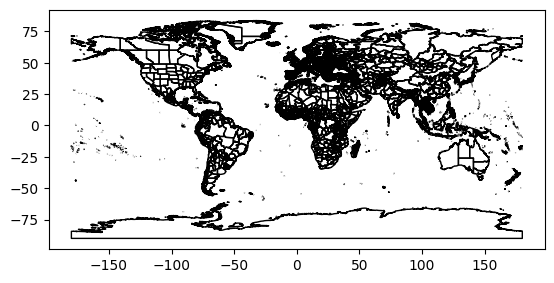

In [12]:
gdf_query.plot(color='None')